# Degradation

In this tutorial, we explain the basics of degradation modeling with nest-soc.

Degradation simulation is an extension of the basic simulations covered in the previous tutorial (see [1_basics.ipynb](1_basics.ipynb)), but now some of the cell properties change with time.

## The basic model definition

Similarly as covered in the previous tutorial, we can create a basic model from defining the **Species**, **Mixtures**, **Layers**, **Cell** and **Boundary**.

Here we will take for granted a starting cell model similar to the one used in the previous tutorial:

In [1]:
# 1. Importing packages
from nest import cell, layers, properties, boundary

# 2. Define Species and Mixture
fuel_mix = properties.Mixture((properties.BasicSpecies.H2, properties.BasicSpecies.H2O))
air_mix = properties.Mixture((properties.BasicSpecies.O2, properties.BasicSpecies.N2))

# 3. Define cell Layers with their properties (kinetic, transport, conductivity, etc.)
Ni_YSZ = layers.Layer(
    delta=1000e-6 + 10e-6,
    kinetic=layers.ButlerVolmer(
        fuel_mix,
        nu=[-1, 1],
        n_e=2,
        alpha=0.59,
        beta=1 - 0.59,
        gamma=1.82527e6,
        p=[-0.1, 0.33],
        theta=1,
        E_act=1.09 / 8.617333262e-5 * 8.314510,
    ),
    transport=layers.BinaryFick(
        dp=600e-9,
        epsilon=0.3,
        tau=2,
    ),
)
YSZ = layers.Layer(
    delta=8e-6 - 1.5e-6,
    conductivity=layers.Conductivity(
        sigma0=3.6e7,
        E_act=8e4,
    ),
)
YSZ_CGO = layers.Layer(
    delta=3e-6,
    conductivity=layers.Conductivity(sigma0=1715, E_act=8785 * 8.314510, theta=0),
)
CGO = layers.Layer(
    delta=5e-6 - 1.5e-6,
    conductivity=layers.Conductivity(
        sigma0=1.09e7,
        E_act=0.64 / 8.617333262e-5 * 8.314510,
    ),
)
LSCF_CGO = layers.Layer(
    delta=32e-6,
    kinetic=layers.ButlerVolmer(
        air_mix,
        alpha=0.65,
        beta=1 - 0.65,
        gamma=1.51556e8,
        nu=[-0.5, 0.0],
        E_act=1.45 / 8.617333262e-5 * 8.314510,
        p=[0.22, 0.0],
    ),
    transport=layers.BinaryFick(dp=6e-7, epsilon=0.3, tau=2.8),
)

# 4. Define cell from the layers
cellModel = cell.Cell(16e-4, Ni_YSZ, (YSZ, YSZ_CGO, CGO), LSCF_CGO)

# 5. Define boundary conditions
n_fuel = 8.23e-05  # mol/s
n_air = 0.000345476  # mol/s
x_H2 = 0.94
x_O2 = 0.21
conditions = boundary.BoundaryData(
    V=0.7,
    j=0.7e4,
    n_fuel=[n_fuel * x_H2, n_fuel * (1 - x_H2)],
    n_air=[n_air * x_O2, n_air * (1 - x_O2)],
    T=700 + 273.15,
    P=1e5,
)

# 6. Solve for voltage (just a check)
solution = cellModel.solve_for_voltage(conditions)
print(f"The average current density is {solution[1].mean()} A/cm2")

The average current density is 6964.348359560108 A/cm2


As we can see, the model can calculate the current density for an specific condition.

Now we need to add degradation mechanisms so that we can estimate how the voltage/current evolves with time.

For fuel cell operation, three main degradation sources can be listed:
* Nickel agglomeration (fuel electrode degradation)
* Chromium poisoning (air electrode degradation)
* Ohmic resistance increase due to interconnect oxidation

The two first source are related with the electrodes and have kinetic nature, while the third is related with the ohmic resistance.

## Kinetic degradation

Both nickel agglomeration and chromium poisoning can be categorized as **kinetic** type degradation.

They may have different physical mechanisms, such as contaminants blocking reaction sites or growing sizes of particles, but their impact on **modeling** is very similar.

The general approach used in nest-soc is to treat degradation of **kinetic** type as an alteration of the pre-exponential factor in the Butler-Volmer reaction (i.e., $\gamma$)

> As a reminder, the Butler-Volmer reaction can be written as:
> $$j = j_0 \left [ \exp \left( \alpha \frac{n_e F}{RT}\eta_{act} \right) - \exp \left( -\beta \frac{n_e F}{RT} \eta_{act} \right) \right] $$
>
> In which, 
> $$ j_0 = \gamma T^\theta  \exp \left ( \frac{E_{act}}{RT} \right) \prod \left( \frac{P_i}{P_0} \right)^{p_i} $$
> See [basics tutorial](1_basics.ipynb) for more details

Therefore, a degradation mechanism can be written as a certain differential equation ($\frac{dr}{dt} = f(...)$) that expresses the relative change of $\gamma$ compared with the initial state. For example:

$$r(t) = \frac{\gamma (t)}{\gamma(0)}$$

$$\frac{dr}{dt} = f(j,V,T,...)$$

In which,
* r : normalized pre-exponential factor in relation with the initial value [-].
* t : time [h]
* $\gamma$ : pre-exponential factor [A/cm^2]
* j : current density [A/cm^2]
* V : voltage [V] 
* T : temperature [K]

These degradation equations can be customized as a class object of type **Degradation**.

The nest-soc provides pre-builded objects for both Chromium poisoning as well as Nickel agglomeration.

### Chromium poisoning

For example, a chromium poisoning model can be written as:

$$ \frac{dr}{dt} = - k \cdot j_{Cr}\cdot r $$

$$ j_{Cr} = j_0 \cdot \exp \left ( \frac{E_{act}}{RT} \right ) \left ( \frac{P_{CrO_2}}{P_0} \right)^{0.5} x_{H_2O}^{0.5} \cdot 2 \cdot \sinh \left ( \frac{1}{2}\frac{F}{RT}\eta_{act,air} \right )  $$

$$ P_{CrO_2} = 2.26 \cdot 10^{-2} \cdot (P\cdot x_{H_2O})^{0.992} \exp \left ( \frac{-6.7\cdot 10^4}{RT} \right ) $$

In which,
* k : unit conversion constant [m^2/A]
* $j_{Cr}$ : current density of the chromium deposition [A/m^2]
* **$j_0$ : pre-exponential factor [A/m^2]**
* **$E_{act}$ : activation energy [J/mol]**
* R : gas constant [J/mol.K]
* T : temperature [K]
* $P_{CrO_2}$ : partial pressure of $CrO_2$ [Pa]
* $P_0$ : reference pressure [Pa]
* $x_{H_2O}$ molar fraction of steam in air [-]
* F : Faraday constant [A.s/mol]
* $\eta_{act,air}$ : activation overpotential - air electrode [V]

Thus, the pre-builded class for Cr poisoning requires the user to define two fitted variables ($j_0$, $E_{act}$) and one operational variable ($x_{H2O}$):

In [2]:
from nest import degradation

# Defining Cr poisoning model
Cr_poisoning = degradation.ChromiumPoison(
    x_H2O=0.01,
    j0=4.27254e7,
    E_act=1.45 / 8.617333262e-5 * 8.314510,
)

# Updating the air electrode layer with the degradation model
LSCF_CGO.degradation = Cr_poisoning

### Nickel agglomeration

The nickel agglomeration model calculates the rate of change of the nickel radius.

It uses it to calculate the triple phase boundary length, a microstructure parameter that is an indicator of the active reaction area.

The model can be described as:

$$ \frac{dr_{ed}}{dt} = \frac{\alpha}{16} \frac{1}{(2\cdot r_{ed})^7} \frac{\psi_{ed}}{\psi_{el}A_{el}} \left ( \frac{P_{H_2}}{P_{H_2O}^{0.5}} \right) \exp \left ( - \frac{E_{act}}{RT} \right) $$

$$ \lambda(t) =   f(r_{ed},r_{el},\psi_{ed},\psi_{el},...) $$

$$ \gamma(t) = \frac{\gamma}{\lambda_{ref}} \cdot \lambda(t) $$

In which,
* $r_{ed}$ : Nickel particle radius (μm);
* **$\alpha$ : Fitted kinetic factor [$μm^7/(h.bar^{0.5})$]**
* $\phi_{ed}$ : Solid phase fraction - Ni [-]
* $\phi_{el}$ : Solid phase fraction - YSZ [-]
* $A_{el}$ : specific surface area of all YSZ-particles per unit volume [1/μm]
* $P_{H_2}$ : partial pressure of hydrogen [bar]
* $P_{H_2O}$ : partial pressure of steam [bar]
* **$E_{act}$ : activation energy [J/mol.K]**
* $\lambda$ : triple phase boundary length [1/m^2]
* $\lambda_{ref}$ : reference triple phase boundary length [1/m^2]
* $f(r_{ed},r_{el},\psi_{ed},\psi_{el},...)$: the percolation model function relating material properties and the TPB length

In [3]:
# Defining Ni agglomeration model
Ni_agglomeration = degradation.NickelAgglomeration(
    # Material properties
    psi_ed=0.4,
    psi_el=0.6,
    r0_ed=300e-9,
    r0_el=300e-9,
    epsilon=0.3,
    # Fitting parameters
    alpha=3.04e8,
    E_act=242e3,
    r_ed_max=500e-9,
)

# Updating the fuel electrode layer with the degradation model
Ni_YSZ.degradation = Ni_agglomeration
# Normalizing the kinetic pre-factor to the initial conditions
Ni_YSZ.kinetic.gamma = 1.82527e6 / 4.19e12  # gamma/lambda_ref

## Ohmic degradation
Ohmic degradation are detrimental changes in the ohmic resistance of the cell.

For instance, this can happen by (i) growth of a new layer that offers charge resistance or (ii) the change in conductivity of the material layer.

In any case, the degradation can be calculated by introducing a factor to the ohmic resistance that varies over time (r):

$$ R = \frac{\delta+r(t)}{\sigma} $$

$$ \frac{dr}{dt} = f(j,V,T,...) $$

In which,
* R : layer ohmic area specific resistance [ohm.m2]
* $r(t)$ : degradation factor at time t [-]  
* $\delta$ : layer thickness [m]
* $\sigma$ : layer conductivity [S/m]

### Interconnect corrosion

Differently from the previous examples, the interconnect corrosion can be classified as an **ohmic type** degradation.

In other words, the interconnect corrosion causes an increase in ohmic overpotential due to the growth of an extra layer of oxide scale.

The growth of the oxide scale can be adapted to the nest-soc framework by setting the initial thickness to zero:

$$ R_{ox} = \frac{r(t)}{\sigma_{ox}} $$

$$ \frac{dr^2}{dt} = k_{mg} \cdot \exp \left ( - \frac{E_{ox}}{RT} \right ) $$

In which,
* $r^2$ : squared of oxide scale thickness at time t [m]
* **$k_{mg}$ : kinetic pre-exponential factor [m^2]**
* **$E_{ox}$ : activation energy of oxide scale growth [J/mol.K]**

In the code, this means we should define a new layer for the oxide scale including the specific degradation mechanism:

In [4]:
CrScale = layers.Layer(
    delta=0,
    conductivity=layers.Conductivity(sigma0=45.8, E_act=33.3e3, theta=0),
    degradation=degradation.InterconnectOxidation(k_mg=0.02361, E_ox=260_000),
)

## Updated model with degradation

Now we can update the cell model including the updated layers with degradation mechanisms

In [5]:
# Define cell
cellModel = cell.Cell(16e-4, Ni_YSZ, (YSZ, YSZ_CGO, CGO, CrScale), LSCF_CGO)

To solve the problem, we call a special method called **solve_for_time**:

        cell.solve_for_time(Boundary, "type", time)

So, for a case of constant current operation during 5000 hours we have:

In [6]:
# Solve ODE problem
solution_time = cellModel.solve_for_time(conditions, "current", 5000)

Here the solutions follow a different structure compared to the previous example, as the are default object from solving a ODE with the scipy package:

* solution_time.t : holds the time values for each step calculated in the integration [h]
* solution_time.y : holds the evolution of the degradation ratio fators.

The degradation ratios are order in the following structure:

$$ y = [r_{fuel,1}, r_{air,1}, r_{fuel,2}, r_{air,2}, ..., r_{fuel,n_{el}}, r_{air,n_{el}}, r_{ohm,1}, ..., r_{ohm,n_{el}}, P_{cum.} ] $$

In which,
* $r_{fuel,i}$ : kinetic degradation ratio for fuel electrode at element number i
* $r_{air,i}$ : kinetic degradation ratio for air electrode at element number i
* $r_{ohm,i}$ : ohmic degradation ratio for a layer at element number i
* $n_{el}$ : total number of elements
* $P_{cum.}$ cumulative power consumption/production [W]

If there are more than one layer with ohmic degradation, they will appear first per layer and secondly per element, similar to the kinetic degradation ratios.

For example, in the case of two layers (A and B):

$$ y = [..., r_{ohm,A,1}, r_{ohm,B,1}, r_{ohm,A,2}, r_{ohm,B,2}, ...  ]

### Plotting the results

Following the aforementioned structure, we can plot the variation of each degradation factor for each segment to observe the differences in space and time.

For example, in the case of Nickel agglomeration:

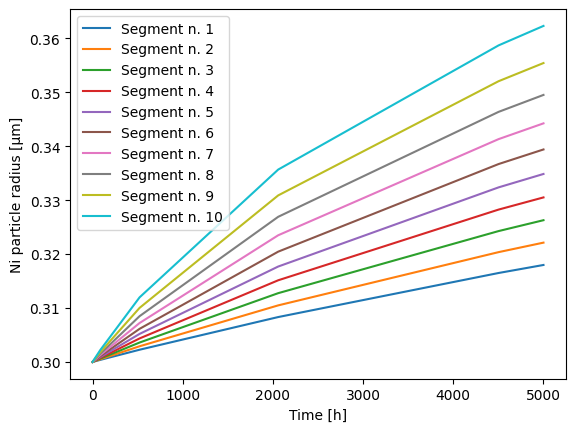

In [7]:
import matplotlib.pyplot as plt
import numpy as np

n_el = cellModel.elements

r_Ni = np.transpose(solution_time.y[0 : n_el * 2 : 2])
plt.plot(solution_time.t, r_Ni, label=[f"Segment n. {i + 1}" for i in range(n_el)])
plt.legend()
plt.ylabel("Ni particle radius [μm]")
plt.xlabel("Time [h]")
plt.show()

Similarly for Cr poisoning:

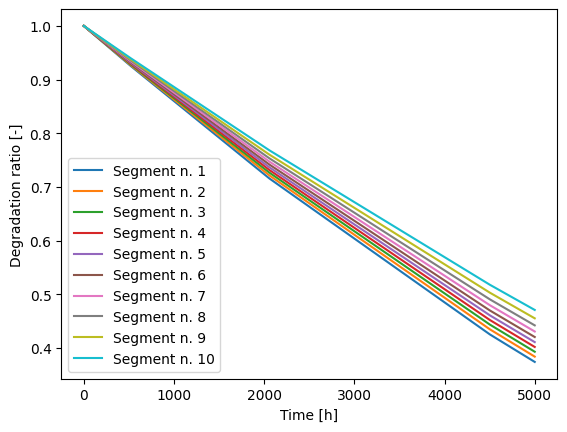

In [8]:
r_Cr = np.transpose(solution_time.y[1 : n_el * 2 : 2])

plt.plot(solution_time.t, r_Cr, label=[f"Segment n. {i + 1}" for i in range(n_el)])
plt.legend()
plt.ylabel("Degradation ratio [-]")
plt.xlabel("Time [h]")
plt.show()

Finally, for the interconnect oxidation:

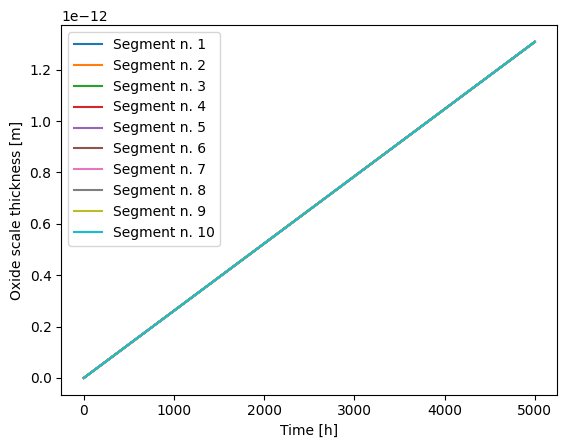

In [9]:
r_ox = np.transpose(solution_time.y[n_el * 2 : n_el * 3])

plt.plot(solution_time.t, r_ox, label=[f"Segment n. {i + 1}" for i in range(n_el)])
plt.legend()
plt.ylabel("Oxide scale thickness [m]")
plt.xlabel("Time [h]")
plt.show()

### Extracting voltage/current evolution

As you may have noticed, the solution_time does not provide any direct information on the voltage/current or other parameters that may be of our interest.

In order to do this, we need to use anoter method called **solve_time_step**

        solve_time_step(y[i], conditions, "method" )

This will provide a solution for a specific time step following the same format as in the steady state simulations (i.e., like in the basics tutorial)

For instance, to determine the voltage in the begining and end of the simulation, we can run the method with the first and last element of the y solutions (after transposing):

In [10]:
import numpy as np

y_matrix = np.transpose(solution_time.y)

solution = cellModel.solve_time_step(y_matrix[0], conditions, "current")
print(f"The voltage at the beginning of the simulation was {np.average(solution[0])} V")

solution = cellModel.solve_time_step(y_matrix[-1], conditions, "current")
print(f"The voltage at the end of the simulation was {np.average(solution[0])} V")

The voltage at the beginning of the simulation was 0.6790261047197121 V
The voltage at the end of the simulation was 0.6058245934825258 V


We can repeat the process for all time entries to create a plot of voltage evolution and compare with [experimental data](../data/700C_75FU_40AIR.csv):

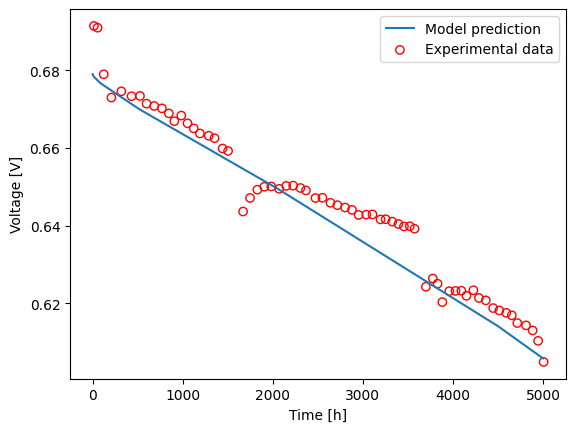

In [11]:
import pandas as pd

# Creating the voltage vector
V = np.zeros(len(solution_time.t))

# Looping the solution to get the voltage at each time step
conditions.V = 0.9
for i, y in enumerate(y_matrix):
    solution = cellModel.solve_time_step(y, conditions, "current")
    V[i] = np.average(solution[0])

# Reading the experimental data
exp_data = pd.read_csv("../data/700C_75FU_40AIR.csv")

# Plotting the voltage over time
plt.plot(solution_time.t, V, label="Model prediction")
plt.scatter(
    exp_data["t"],
    exp_data["V"],
    edgecolors="r",
    facecolor="none",
    label="Experimental data",
)
plt.ylabel("Voltage [V]")
plt.xlabel("Time [h]")
plt.legend()
plt.show()

## Activity 1 : extracting degradation rates for different current densities

**Problem** : Using the model in this example, calculate the degradation rates (mΩ/kh) for different current densities from 0.1-0.7 A/cm2

**Answer** : Here is a code example that accomplishes this task:

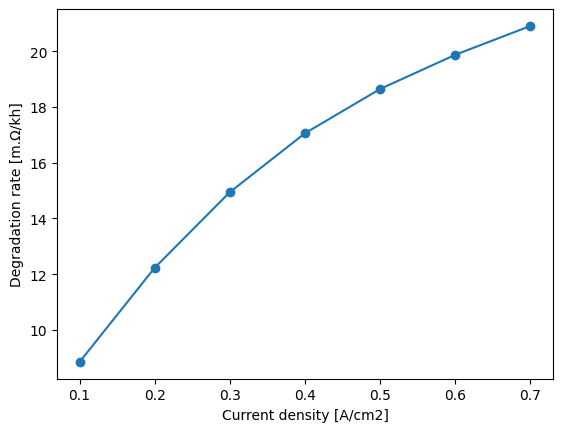

In [12]:
# 1. Creating arrays for current density and degradation rates
current_density = np.linspace(0.1e4, 0.7e4, 7)
degradation_rates = np.zeros(len(current_density))

# 2. Looping over the current densities to get the degradation rate at each current density
conditions.V = 0.69  # initial guess for low current density
for i, j in enumerate(current_density):
    # 2.1. Solving for specific current density
    conditions.j = j
    solution_time = cellModel.solve_for_time(conditions, "current", 5000)

    # 2.2 Getting the voltage at the beginning and end of the simulation
    y_matrix = np.transpose(solution_time.y)
    solution_begin = cellModel.solve_time_step(y_matrix[0], conditions, "current")
    solution_end = cellModel.solve_time_step(y_matrix[-1], conditions, "current")

    # 2.3 Storing the degradation rate as resistance increase per 1000 hours
    degradation_rates[i] = (
        (np.average(solution_begin[0]) - np.average(solution_end[0]))
        * 1000
        / (j / 1e4)
        / 5
    )

# 3. Plotting results
plt.plot(current_density * 1e-4, degradation_rates, marker="o")
plt.xlabel("Current density [A/cm2]")
plt.ylabel("Degradation rate [m.Ω/kh]")
plt.show()

## Activity 2 : lazy degradation model

**Problem** : Using the experimental data as a reference, build a "lazy" degradation model using an equivalent ASR and degradation rate.

**Answer** : Here is a code example that acomplishes this task

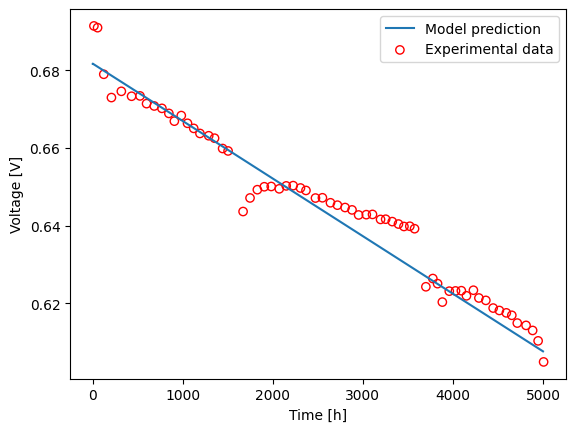

In [13]:
# 1. Create an equivalent layer to represent the cell resistance
ASR = 0.43  # Ohm*cm2, estimated from the experimental data near the OCV
equivalent_layer = layers.Layer(
    delta=1,
    conductivity=layers.Conductivity(
        sigma0=1e4 / ASR,  # converted into S/m
        theta=0,  # Important to set theta as zero, because the default is 1
    ),
)

# 2. Create dummy layers for the electrodes with the minimal data required for the molar balances and thermodynamic voltage calculation
dummy_fuel = layers.Layer(
    delta=1,
    kinetic=layers.Kinetic(gas=fuel_mix, nu=[-1, 1]),
)
dummy_air = layers.Layer(
    delta=1,
    kinetic=layers.Kinetic(gas=air_mix, nu=[-0.5]),
)

# 3. Create the cell with the equivalent layer and dummy electrodes
lazy_cell = cell.Cell(
    area=16e-4,
    electrode_fuel=dummy_fuel,
    electrolyte=(equivalent_layer,),
    electrode_air=dummy_air,
)

conditions.V = 0.69
conditions.j = 0.7e4


# 4. Creating a dummy degradation model class
class DummyDegradation(degradation.Degradation):
    def material_dt(self, m, state, time, **kwargs):
        return 5e-5

    def pol_deg(self, m, **kwargs):
        return 0

    def ohm_deg(self, m, **kwargs):
        return m


# 5. Including and activating the degradation model
lazy_cell.electrolyte[0].degradation = DummyDegradation()
lazy_cell.electrolyte[0].degradation.ohm_active = True

# 6. Solving the problem
solution_time = lazy_cell.solve_for_time(conditions, "current", 5000)

# 7. Reusing code for extracting voltage adn plotting results
V = np.zeros(len(solution_time.t))
y_matrix = np.transpose(solution_time.y)
for i, y in enumerate(y_matrix):
    solution = lazy_cell.solve_time_step(y, conditions, "current")
    V[i] = np.average(solution[0])
plt.plot(solution_time.t, V, label="Model prediction")
plt.scatter(
    exp_data["t"],
    exp_data["V"],
    edgecolors="r",
    facecolor="none",
    label="Experimental data",
)
plt.ylabel("Voltage [V]")
plt.xlabel("Time [h]")
plt.legend()
plt.show()